# Autoevaluación de generación de antecedentes del FIS de Sugeno

Se tienen los siguientes datos de la evolución del COVID-19 en China durante 2020:

[5,	6,	4,	7,	9,	6,	7,	4,	8,	16,	9,	14,	9,	15,	7,	11,	22,	17,	23,	27,	28,	30,	31,	37,	32,	42,	35,	47,	44,	29,	52,	70,	150,	98,	109,	118,	112,	139,	98,	105,	142,	143,	13,	254,	97,	108,	97,	89,	86,	73,	72,	66,	65,	57,	45,	46,	43,	38,	26,	25,	25,	15,	15,	9,	0,	11,	3,	0,	1,	0,	0,	0,	1,	0,	0,	0,	1,	0,	0,	0,	0,	0,	0,	0,	0,	0,	0,	0]

In [2]:
import numpy as np
import pandas as pd

evolucion = np.array([5, 6,	4,	7,	9,	6,	7,	4,	8,	16,	9,	14,	9,	15,	7,	11,	22,	17,	23,	27,	28,	30,	31,	37,	32,	42,	35,	47,	44,	29,	52,	70,	150,	98,	109,	118,	112,	139,	98,	105,	142,	143,	13,	254,	97,	108,	97,	89,	86,	73,	72,	66,	65,	57,	45,	46,	43,	38,	26,	25,	25,	15,	15,	9,	0,	11,	3,	0,	1,	0,	0,	0,	1,	0,	0,	0,	1,	0,	0,	0,	0,	0,	0,	0,	0,	0,	0,	0])
df = pd.DataFrame({
    "dia": np.arange(1, len(evolucion) + 1),
    "evolucion": evolucion
})

1. Aplicar un método de cluster, por ejemplo Fuzzy C Means para encontrar dos centros de cluster.
2. Calcular el ancho de las funciones de pertenencia utilizando la fórmula que aparece en el video anterior.
3. Graficar las dos gaussianas con el centro y dispersión asociados a los clusters hallados.
4. Repita para 3 clusters.

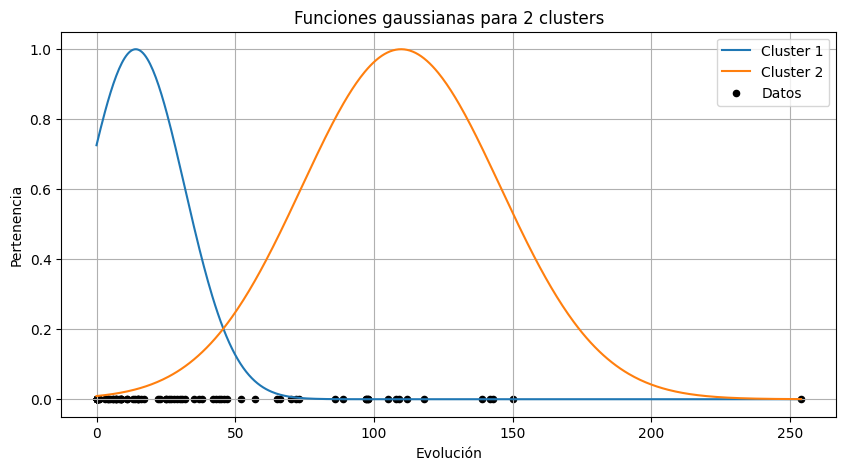

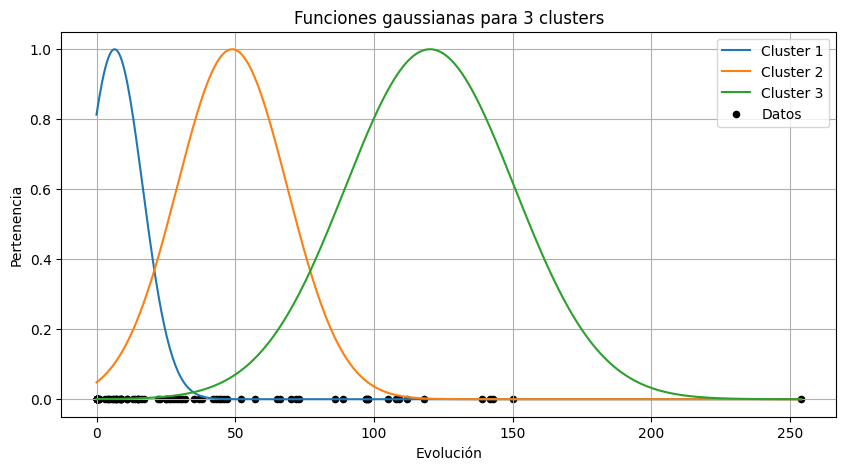

In [ ]:
import skfuzzy as fuzz
import matplotlib.pyplot as plt

datos = df["evolucion"].to_numpy(dtype=float).reshape(1, -1)


def agrupar_y_graficar(numero_clusters: int
                       ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Aplica el algoritmo de clustering difuso y grafica las funciones gaussianas resultantes.
    
    Args:
        numero_clusters (int): Número de clusters a generar.

    Returns:
        tuple[np.ndarray, np.ndarray, np.ndarray]: Tupla con los centros, anchos y pertenencias de los clusters.
    """
    centros, pertenencias, _, _, _, _, _ = fuzz.cluster.cmeans(
        datos,
        c=numero_clusters,
        m=2,
        error=0.005,
        maxiter=1000,
        seed=42
    )

    centros = centros.ravel()
    orden = np.argsort(centros)
    centros = centros[orden]
    pertenencias = pertenencias[orden]

    # Dispersión ponderada de cada cluster
    anchos = np.sqrt(
        np.sum(
            pertenencias**2 * (datos[0] - centros[:, None])**2,
            axis=1
        )
        / np.sum(pertenencias**2, axis=1)
    )
    anchos = np.maximum(anchos, 1e-6)

    x = np.linspace(datos.min(), datos.max(), 500)

    plt.figure(figsize=(10, 5))
    for i, (centro, ancho) in enumerate(zip(centros, anchos), start=1):
        gaussiana = np.exp(-0.5 * ((x - centro) / ancho) ** 2)
        plt.plot(x, gaussiana, label=f"Cluster {i}")

    plt.scatter(
        df["evolucion"],
        np.zeros(len(df)),
        color="black",
        s=20,
        label="Datos"
    )
    plt.xlabel("Evolución")
    plt.ylabel("Pertenencia")
    plt.title(f"Funciones gaussianas para {numero_clusters} clusters")
    plt.legend()
    plt.grid()
    plt.show()

    return centros, anchos, pertenencias


centros_2, anchos_2, pertenencias_2 = agrupar_y_graficar(2)
centros_3, anchos_3, pertenencias_3 = agrupar_y_graficar(3)